In [1]:
print("hello jay")

hello jay


In [38]:
from dotenv import load_dotenv
import os
load_dotenv()

True

In [3]:
from langchain_groq import ChatGroq

In [4]:
llm = ChatGroq(api_key=os.getenv("GROQ_API_KEY"), model=os.getenv("LLM_MODEL"))

In [5]:
llm.invoke("What is capital of india")

AIMessage(content='The capital of India is New Delhi.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 40, 'total_tokens': 49, 'completion_time': 0.006485569, 'completion_tokens_details': None, 'prompt_time': 0.002217566, 'prompt_tokens_details': None, 'queue_time': 0.045938593, 'total_time': 0.008703135}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ca365-41bd-7020-aa68-55999f490179-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 40, 'output_tokens': 9, 'total_tokens': 49})

In [6]:
from typing_extensions import TypedDict, Annotated
import operator

In [7]:
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage

In [8]:
class GraphState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [9]:
def llm_call(state: GraphState) -> dict:
    """Call the LLM using conversation messages and append AI response."""
    response = llm.invoke(state["messages"])  # AIMessage
    return {
        "messages": [response]
    }

In [10]:
def token_counter(state: GraphState) -> dict:
    """Count tokens (simple word count) in the last AI message."""
    last_msg = state["messages"][-1]
    text = last_msg.content
    token_number = len(text.split())
    summary = f"Total token number in the generated answer (word count) is {token_number}"
    return {
        "messages": [AIMessage(content=summary)]
    }

In [11]:
from langgraph.graph import StateGraph

In [12]:
builder = StateGraph(GraphState)

In [13]:
builder.add_node("llm_call", llm_call)
builder.add_node("token_counter", token_counter)

In [14]:
builder.set_entry_point("llm_call")
builder.add_edge("llm_call", "token_counter")
builder.set_finish_point("token_counter")

In [15]:
app = builder.compile()

In [16]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

In [17]:
from IPython.display import Image, display

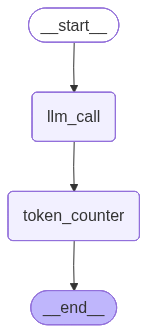

In [18]:
display(Image(app.get_graph().draw_mermaid_png()))

In [19]:
result = app.invoke({
    "messages": [HumanMessage(content="Hi, this is jay. Say hello in detail.")]
})

In [20]:
result

{'messages': [HumanMessage(content='Hi, this is jay. Say hello in detail.', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Hello Jay, it\'s great to connect with you. I hope you\'re doing fantastically well and enjoying your day. I\'d like to take a moment to acknowledge you and express my digital warm welcome. \n\nA simple "hello" can sometimes convey so much more than we think. It\'s a greeting that signifies respect, kindness, and a willingness to engage with someone. It\'s a fundamental aspect of human interaction, cutting across cultures, languages, and geographical boundaries.\n\nIn this digital age, where we often rely on screens and keyboards to communicate, a heartfelt "hello" can bring a touch of warmth and personality to an otherwise impersonal exchange. It\'s a way to break the ice, establish a connection, and set a positive tone for the conversation that follows.\n\nSo, Jay, I\'m glad we\'re taking a moment to say hello. I hope you\'re feeling energized,

In [21]:
for m in result["messages"]:
    print(type(m).__name__, ":", m.content)

HumanMessage : Hi, this is jay. Say hello in detail.
AIMessage : Hello Jay, it's great to connect with you. I hope you're doing fantastically well and enjoying your day. I'd like to take a moment to acknowledge you and express my digital warm welcome. 

A simple "hello" can sometimes convey so much more than we think. It's a greeting that signifies respect, kindness, and a willingness to engage with someone. It's a fundamental aspect of human interaction, cutting across cultures, languages, and geographical boundaries.

In this digital age, where we often rely on screens and keyboards to communicate, a heartfelt "hello" can bring a touch of warmth and personality to an otherwise impersonal exchange. It's a way to break the ice, establish a connection, and set a positive tone for the conversation that follows.

So, Jay, I'm glad we're taking a moment to say hello. I hope you're feeling energized, motivated, and ready to tackle whatever the day has in store for you. If there's anything I

In [22]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [24]:
api_wrapper=WikipediaAPIWrapper(top_k_results=5,doc_content_chars_max= 500)

In [25]:
wiki_tool=WikipediaQueryRun(api_wrapper=api_wrapper)

In [26]:
wiki_tool.run({"query":"Generative AI"})

'Page: Generative artificial intelligence\nSummary: Generative artificial intelligence, also known as generative AI or GenAI, is a subfield of artificial intelligence that uses generative models to generate text, images, videos, audio, software code or other forms of data. These models learn the underlying patterns and structures of their training data, and use them to generate new data in response to input, which often takes the form of natural language prompts.\nThe prevalence of generative AI to'

In [39]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")

In [40]:
os.getenv("TAVILY_API_KEY")

'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'

In [41]:
tool=TavilySearchResults(tavily_api_key=TAVILY_API_KEY)

In [42]:
tool.invoke({"query":"how is the job market for fresh graduates in 2026?"})

[{'title': 'Hiring Flat for the College Class of 2026 - NACE',
  'url': 'https://www.naceweb.org/job-market/trends-and-predictions/hiring-flat-for-the-college-class-of-2026',
  'content': 'Reflecting an uncertain job market for college graduates, employers are projecting just a 1.6% increase in hiring for the Class of 2026 when compared to the Class of 2025, according to results of NACE’s Job Outlook 2026 survey.\n\nThat flat hiring projection is consistent with the tight labor market employers reported at the end of the 2024-25 recruiting year. (See Figure 1.)\n\nThese findings are also consistent with what NACE is seeing with general employment indicators at large. NACE found that employers are less positive about the overall job market for upcoming graduates this year than they were in last several years. Currently, a plurality of employers rate the overall job market for new graduates as "fair," compared to a year ago, when they characterized it as "good." (See Figure 2.) [...] Add

In [43]:
from langchain_community.tools import YouTubeSearchTool

In [44]:
tool=YouTubeSearchTool()

In [45]:
tool.name

'youtube_search'

In [46]:
tool.description

'search for youtube videos associated with a person. the input to this tool should be a comma separated list, the first part contains a person name and the second a number that is the maximum number of video results to return aka num_results. the second part is optional'

In [47]:
tool.run("codejay")

"['https://www.youtube.com/watch?v=jghcSqQXYT8&pp=ygUHY29kZWpheQ%3D%3D', 'https://www.youtube.com/watch?v=hD33bmQaVww&pp=ygUHY29kZWpheQ%3D%3D']"

Custom tool

In [48]:
from langchain.tools import tool

In [49]:
@tool
def multiply(a:int,b:int) -> int:
    '''this tool is for the multiplication'''
    return a*b

In [50]:
multiply.invoke({"a":10,"b":20})

200

In [51]:
multiply.name

'multiply'

In [52]:
multiply.description

'this tool is for the multiplication'

In [53]:
multiply.args

{'a': {'title': 'A', 'type': 'integer'},
 'b': {'title': 'B', 'type': 'integer'}}

In [56]:
import yfinance as yf

In [57]:
@tool
def get_stock_price(ticker:str) -> str: 
    """this is a tool to get stock price using yfinance"""
    try:
        stock = yf.Ticker(ticker)

        # Get last 1 day historical data
        data = stock.history(period="1d")

        if data.empty:
            return f"No data found for ticker '{ticker}'. Please check the symbol."

        latest_close = data["Close"].iloc[-1]

        # Detect currency
        currency = stock.info.get("currency", "")
        symbol_map = {
            "INR": "₹",
            "USD": "$",
            "EUR": "€",
            "GBP": "£"
        }

        symbol = symbol_map.get(currency, "")
        currency_text = currency if currency else ""

        if symbol:
            return f"The last closing price of {ticker.upper()} was {symbol}{latest_close:.2f}."
        else:
            return f"The last closing price of {ticker.upper()} was {latest_close:.2f} {currency_text}."

    except Exception as e:
        return f"An error occurred while fetching stock data: {str(e)}"


In [58]:
get_stock_price.invoke("TCS.NS")

'The last closing price of TCS.NS was ₹2637.40.'

In [59]:
get_stock_price.invoke("HDFCBANK.NS")

'The last closing price of HDFCBANK.NS was ₹887.75.'

In [61]:
tools = [get_stock_price,multiply,wiki_tool]

In [62]:
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001C3716A6810>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001C37129CD10>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [63]:
llm_with_tools=llm.bind_tools(tools)

In [64]:
result = llm_with_tools.invoke("what is the stock price of TCS.NS?")

In [67]:
result.content

''

In [66]:
result.tool_calls

[{'name': 'get_stock_price',
  'args': {'ticker': 'TCS.NS'},
  'id': 'y03xwvqwn',
  'type': 'tool_call'}]

In [68]:

result = llm_with_tools.invoke("hi how are you?")

In [69]:
result.content

"I'm just a language model, I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you with any questions or tasks you may have. What can I help you with today?"

In [70]:
result.tool_calls

[]

In [71]:
result = llm_with_tools.invoke("what was in the latest indian union budget report of 2026?")

In [72]:
result.content

''

In [73]:
result.tool_calls

[{'name': 'wikipedia',
  'args': {'query': 'Indian Union Budget Report 2026'},
  'id': 'ep8s4ytw6',
  'type': 'tool_call'}]

In [74]:
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import MessagesState,StateGraph, END, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [75]:
SYSTEM_PROMPT = SystemMessage(content="You are a helpful assistant that can use tools to answer questions.")

In [76]:
def function_1(state:MessagesState):
    user_question=state["messages"]
    input_question =[SYSTEM_PROMPT] + user_question
    response = llm_with_tools.invoke(input_question)
    return{
        "messages":[response]
    }

In [77]:
tools

[StructuredTool(name='get_stock_price', description='this is a tool to get stock price using yfinance', args_schema=<class 'langchain_core.utils.pydantic.get_stock_price'>, func=<function get_stock_price at 0x000001C372B2DDA0>),
 StructuredTool(name='multiply', description='this tool is for the multiplication', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x000001C372C32DE0>),
 WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\Users\\jaypr_ughx7yt\\OneDrive\\Desktop\\Research Paper Agentic AI Project\\.venv\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=5, lang='en', load_all_available_meta=False, doc_content_chars_max=500))]

In [78]:
function_2 = ToolNode(tools)

In [88]:
workflow = StateGraph(MessagesState)

In [89]:
workflow.add_node("llm_model", function_1)
workflow.add_node("tools", function_2)
workflow.add_edge(START, "llm_model")

workflow.add_conditional_edges(
    "llm_model",
    tools_condition,
)

workflow.add_edge("tools", "llm_model")

In [90]:
app = workflow.compile()

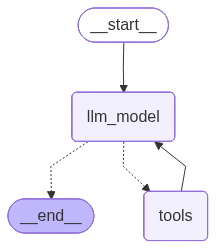

In [91]:

from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [92]:
result = app.invoke({
    "messages": [HumanMessage(content="what is the stock price of TCS.NS?")]
})

In [93]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

what is the stock price of TCS.NS?
================================== Ai Message ==================================
Tool Calls:
  get_stock_price (jhbq58v6h)
 Call ID: jhbq58v6h
  Args:
    ticker: TCS.NS
================================= Tool Message =================================
Name: get_stock_price

The last closing price of TCS.NS was ₹2637.40.
================================== Ai Message ==================================

However, the function get_stock_price will return the current stock price.


In [94]:
result = app.invoke({
    "messages": [HumanMessage(content="what was in the latest indian union budget report of 2026?")]
})

In [95]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

what was in the latest indian union budget report of 2026?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (ffyhrgmgn)
 Call ID: ffyhrgmgn
  Args:
    query: Latest Indian Union Budget Report 2026
================================= Tool Message =================================
Name: wikipedia

Page: 2025–2026 Iranian protests
Summary: Beginning on 28 December 2025, demonstrations erupted across multiple cities in Iran, amid nationwide unrest against the Iranian government and a deepening economic crisis. This event has been the largest uprising since the 1979 Islamic Revolution. The ensuing crackdown, carried out under Ali Khamenei's and senior officials' order for live fire on protesters, resulted in massacres that left tens of thousands of protesters dead, making them the largest ma
================================== Ai Message ===================

In [96]:
result = app.invoke({
    "messages": [HumanMessage(content="give me the latest AI news count the length of response and multiply that response with the 10.")]
})

In [97]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

give me the latest AI news count the length of response and multiply that response with the 10.
================================== Ai Message ==================================
Tool Calls:
  wikipedia (6657b9vw3)
 Call ID: 6657b9vw3
  Args:
    query: latest AI news
================================= Tool Message =================================
Name: wikipedia

Page: Mistral AI
Summary: Mistral AI SAS (French: [mistʁal]) is a French artificial intelligence (AI) company, headquartered in Paris. Founded in 2023, it has open-weight large language models (LLMs), with both open-source and proprietary AI models. As of 2025 the company has a valuation of more than US$14 billion.

Page: AI slop
Summary: AI slop (also known simply as slop) is digital content made with generative artificial intelligence that is perceived as lacking in effort, quality, or meaning
================================== Ai Message ======